<a href="https://colab.research.google.com/github/gangadharp2010/AIPROJECT/blob/main/demo_Live_Class_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

In [2]:
import mlflow
import os

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [3]:
mlflow.set_experiment("Loan_Status_Experiment")

2026/09/30 17:36:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/30 17:36:01 INFO mlflow.store.db.utils: Updating database tables
2026/09/30 17:36:04 INFO mlflow.tracking.fluent: Experiment with name 'Loan_Status_Experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1790789764420, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790789764420, lifecycle_stage='active', name='Loan_Status_Experiment', tags={}, trace_location=None, workspace='default'>

In [7]:
train_df = pd.read_csv('/content/data.csv')
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
train_df.Loan_Status.value_counts()

,count
Loan_Status,
Y,422
N,192


In [9]:
# let's binary encode, Gender, Married Loan_Status

train_df['Gender'] = train_df['Gender'].map({'Male': 0, 'Female': 1})
train_df['Married'] = train_df['Married'].map({'No': 0, 'Yes': 1})
train_df['Loan_Status'] = train_df['Loan_Status'].map({'N': 0, 'Y': 1})

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    float64
 2   Married            611 non-null    float64
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 62.5+ KB


In [11]:
train_df = train_df.dropna()

# Let's Create Features

In [14]:
feature_columns = ['Gender', 'Married', 'ApplicantIncome', 'LoanAmount', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']
X = train_df[feature_columns]
y = train_df.Loan_Status

In [20]:
mlflow.log_param("feature_columns", feature_columns)

['Gender',
 'Married',
 'ApplicantIncome',
 'LoanAmount',
 'CoapplicantIncome',
 'Loan_Amount_Term',
 'Credit_History']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=5)

In [22]:

depth = 5
criteria = 'entropy'
n_esti = 1000

mlflow.log_param("max_depth", depth)
mlflow.log_param("criterion", criteria)
mlflow.log_param("n_estimators", n_esti)


model = RandomForestClassifier(max_depth=depth, random_state=5, criterion=criteria, n_estimators=n_esti)
model.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, n_estimators=1000,
                       random_state=5)

In [24]:
from sklearn.metrics import accuracy_score

pred_val = model.predict(X_val)
val_acc_score = accuracy_score(y_val, pred_val)

print(f"Training Accuracy: {model.score(X_train, y_train)}, Validation Accuracy: {val_acc_score}")


Training Accuracy: 0.8463541666666666, Validation Accuracy: 0.7916666666666666


In [25]:
mlflow.log_metric("train_accuracy", model.score(X_train, y_train))
mlflow.log_metric("val_accuracy", val_acc_score)

In [29]:
mlflow.end_run()

# Test for Eyes

# Another efficient way to use MLflow

In [39]:
def mlflow_runs(n_est,max_dep,i):
    with mlflow.start_run():

        model_rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_dep, random_state=5)
        model_rf.fit(X_train, y_train)

        pred_val = model_rf.predict(X_val)
        val_acc=accuracy_score(y_val, pred_val)

        pred_train = model_rf.predict(X_train)
        train_acc=accuracy_score(y_train, pred_train)

        run="hyperparameter_run_"+str(i)
        mlflow.set_tag('mlflow.runName',run)
        mlflow.log_param('n_estimators',n_est)
        mlflow.log_param('max_depth',max_dep)
        mlflow.log_param('model_name','RandomForestClassifier')
        mlflow.log_metric('val_acc',val_acc)
        mlflow.log_metric('train_acc',train_acc)
        mlflow.set_tag('data file','data_new.csv')

        mlflow.sklearn.log_model(model_rf, "model", skops_trusted_types=['sklearn.tree._tree.Tree'])


mlflow_runs(10,2,1)
mlflow_runs(20,2,2)
mlflow_runs(40,2,3)
mlflow_runs(10,4,4)
mlflow_runs(20,4,5)
mlflow_runs(40,4,6)
mlflow_runs(10,8,7)
mlflow_runs(20,8,8)
mlflow_runs(40,8,9)

2026/09/30 18:00:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:00:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:00:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:00:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:01:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:01:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:01:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:01:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:01:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [116]:
mlflow_runs(10,8,20)
mlflow_runs(20,8,21)
mlflow_runs(40,8,22)

2026/09/30 18:50:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run hyperparameter_run_20 at: http://127.0.0.1:5000/#/experiments/3/runs/c823cb50aea04b5f813cc86633ed83e0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/09/30 18:50:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run hyperparameter_run_21 at: http://127.0.0.1:5000/#/experiments/3/runs/6c14e0c9f47d4f889ae8187a3e5dfdfb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/09/30 18:51:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run hyperparameter_run_22 at: http://127.0.0.1:5000/#/experiments/3/runs/dc050c16cd3b4f3483c265ae3e47b530
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


# Let's see how we can store a confusion matrix picture in MLflow.

2026/09/30 18:02:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/30 18:02:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


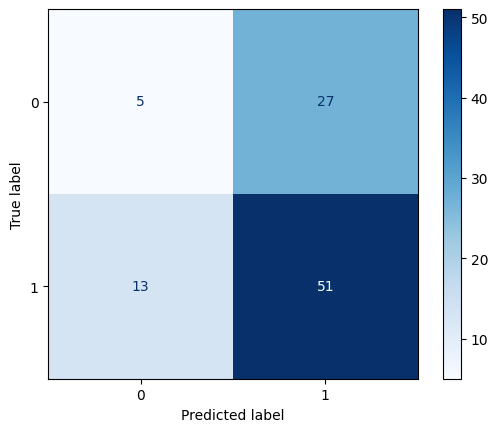

In [41]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib


with mlflow.start_run():
	knn_model= KNeighborsClassifier(n_neighbors=5)
	knn_model.fit(X_train, y_train)

	pred_val = knn_model.predict(X_val)
	val_acc=accuracy_score(y_val, pred_val)

	pred_train = knn_model.predict(X_train)
	train_acc=accuracy_score(y_train, pred_train)

	run="KNN"
	mlflow.set_tag('mlflow.runName',run)
	mlflow.log_param('neighbors',5)
	mlflow.log_metric('val_acc',val_acc)
	mlflow.log_metric('train_acc',train_acc)
	mlflow.log_param('model_name','KNeighborsClassifier')

	cm=ConfusionMatrixDisplay.from_predictions( y_val,pred_val, cmap='Blues')
	cm.figure_.savefig('confusion_mat.png')
	mlflow.log_artifact('confusion_mat.png') # log_artifact can be used to log any file, of any format, e.g. images, text files, etc, with max-size of 5 GB.

	# save dataframe as artifact

	mlflow.log_artifact('/content/data.csv')

	mlflow.sklearn.log_model(knn_model, "model_knn", serialization_format="cloudpickle")

	joblib.dump(knn_model, 'knn_model.joblib')
	mlflow.log_artifact('knn_model.joblib')

In [64]:
!pip install -q mlflow

In [65]:
import subprocess
import time

process = subprocess.Popen(
    [
        "mlflow", "ui",
        "--host", "0.0.0.0",
        "--port", "5000",
        "--backend-store-uri", "/content/mlruns"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("MLflow process running:", process.poll() is None)

MLflow process running: True


In [66]:
!curl -I http://127.0.0.1:5000

curl: (7) Failed to connect to 127.0.0.1 port 5000 after 0 ms: Couldn't connect to server


In [67]:
import subprocess
import time

process = subprocess.Popen(
    [
        "mlflow", "ui",
        "--host", "0.0.0.0",
        "--port", "5000",
        "--backend-store-uri", "sqlite:////content/mlflow.db"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("Process status:", process.poll())

if process.poll() is not None:
    print("MLflow failed to start.")
    print(process.stdout.read())
else:
    print("MLflow is running.")

Process status: None
MLflow is running.


In [68]:
!curl -I http://127.0.0.1:5000

curl: (7) Failed to connect to 127.0.0.1 port 5000 after 0 ms: Couldn't connect to server


In [70]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[m]lflow'"],
    capture_output=True,
    text=True
)

print(result.stdout)

root       17731  7.3  0.0      0     0 ?        Z    18:24   0:07 [mlflow] <defunct>



In [71]:
!mlflow --version

mlflow, version 3.16.1


In [72]:
import os
import subprocess
import time

os.makedirs("/content/mlruns", exist_ok=True)

cmd = [
    "mlflow", "server",
    "--host", "0.0.0.0",
    "--port", "5000",
    "--backend-store-uri", "sqlite:////content/mlflow.db",
]

with open("/content/mlflow.log", "w") as f:
    process = subprocess.Popen(
        cmd,
        stdout=f,
        stderr=subprocess.STDOUT
    )

time.sleep(8)

print("PID:", process.pid)
print("Running:", process.poll() is None)

PID: 18535
Running: True


In [115]:
!cat /content/mlflow.log

Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled. Allowed hosts: *. CORS origins: *.
2026/09/30 18:36:05 ERROR:    [Errno 98] Address already in use
2026/09/30 18:36:13 WARNING mlflow.server.security: MLFLOW_SERVER_CORS_ALLOWED_ORIGINS=* is set; disabling credentialed CORS. Wildcard origins with credentials is a CORS spec violation. Set an explicit origin allowlist to enable credentialed cross-origin requests.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [79]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(5000)")
print(url)

https://5000-m-s-kkb-usc1a1-1303ikqxf3liy-a.us-central1-1.prod.colab.dev


In [80]:
!curl -I http://127.0.0.1:5000

HTTP/1.1 200 OK
date: Wed, 30 Sep 2026 18:30:09 GMT
server: uvicorn
content-disposition: inline; filename=index.html
content-type: text/html; charset=utf-8
content-length: 701
last-modified: Wed, 30 Sep 2026 17:35:10 GMT
cache-control: no-cache
etag: "1790789710.1909633-701-3613006602"
date: Wed, 30 Sep 2026 18:30:10 GMT
accept-ranges: bytes
x-content-type-options: nosniff
x-frame-options: SAMEORIGIN



In [81]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /usr/local/bin/cloudflared

!chmod +x /usr/local/bin/cloudflared

In [82]:
!cloudflared --version

cloudflared version 2026.9.3 (built 2026-09-24-16:07 UTC)


In [84]:
import subprocess
import time
import re

cloudflare = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:5000",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

for _ in range(30):
    line = cloudflare.stdout.readline()

    if line:
        print(line.strip())

        if "trycloudflare.com" in line:
            break

2026-09-30T18:32:33Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-30T18:32:33Z INF Requesting new quick Tunnel on trycloudflare.com...


In [85]:
import subprocess

result = subprocess.run(
    ["bash", "-c", "ps aux | grep '[c]loudflared'"],
    capture_output=True,
    text=True
)

print(result.stdout)

root       19654  0.3  0.2 1294412 39156 ?       Sl   18:31   0:00 cloudflared tunnel --url http://127.0.0.1:5000 --no-autoupdate
root       19994  2.1  0.2 1294412 39480 ?       Sl   18:32   0:00 cloudflared tunnel --url http://127.0.0.1:5000 --no-autoupdate



In [86]:
!pkill -f cloudflared

In [87]:
import time
time.sleep(2)

In [88]:
!ps aux | grep '[c]loudflared'

root       19994  0.6  0.0      0     0 ?        Z    18:32   0:00 [cloudflared] <defunct>


In [89]:
import subprocess
import re
import time

cloudflare = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url", "http://127.0.0.1:5000",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

public_url = None

start = time.time()

while time.time() - start < 30:
    line = cloudflare.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com", line)

        if match:
            public_url = match.group(0)
            break

print("\nMLflow Public URL:")
print(public_url)

2026-09-30T18:33:47Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-30T18:33:47Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-30T18:33:50Z INF +--------------------------------------------------------------------------------------------+
2026-09-30T18:33:50Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-30T18:33:50Z INF |  https://crystal-backgrounds-carmen-reproduced.tryclou

In [90]:
!curl -I http://127.0.0.1:5000

HTTP/1.1 200 OK
date: Wed, 30 Sep 2026 18:34:14 GMT
server: uvicorn
content-disposition: inline; filename=index.html
content-type: text/html; charset=utf-8
content-length: 701
last-modified: Wed, 30 Sep 2026 17:35:10 GMT
cache-control: no-cache
etag: "1790789710.1909633-701-3613006602"
date: Wed, 30 Sep 2026 18:34:15 GMT
accept-ranges: bytes
x-content-type-options: nosniff
x-frame-options: SAMEORIGIN



In [91]:
process.terminate()

In [92]:
!pkill -f "mlflow server"

In [93]:
import subprocess
import time

cmd = [
    "mlflow", "server",
    "--host", "0.0.0.0",
    "--port", "5000",
    "--backend-store-uri", "sqlite:////content/mlflow.db",
    "--allowed-hosts", "*",
    "--cors-allowed-origins", "*"
]

with open("/content/mlflow.log", "w") as f:
    process = subprocess.Popen(
        cmd,
        stdout=f,
        stderr=subprocess.STDOUT
    )

time.sleep(8)

print("MLflow running:", process.poll() is None)

MLflow running: True


In [94]:
!curl -I http://127.0.0.1:5000

curl: (7) Failed to connect to 127.0.0.1 port 5000 after 0 ms: Couldn't connect to server


In [95]:
import subprocess
import time

cmd = [
    "mlflow", "server",
    "--host", "0.0.0.0",
    "--port", "5000",
    "--backend-store-uri", "sqlite:////content/mlflow.db",
    "--allowed-hosts", "*",
    "--cors-allowed-origins", "*"
]

with open("/content/mlflow.log", "w") as f:
    mlflow_process = subprocess.Popen(
        cmd,
        stdout=f,
        stderr=subprocess.STDOUT
    )

time.sleep(10)

print("PID:", mlflow_process.pid)
print("Running:", mlflow_process.poll() is None)

PID: 20895
Running: True


In [96]:
!cat /content/mlflow.log

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [97]:
!ps aux | grep '[m]lflow'

root       20595  7.8  2.0 874132 272760 ?       Sl   18:34   0:05 /usr/bin/python3 /usr/local/bin/mlflow server --host 0.0.0.0 --port 5000 --backend-store-uri sqlite:////content/mlflow.db --allowed-hosts * --cors-allowed-origins *
root       20628  0.4  0.2  38484 28248 ?        S    18:35   0:00 /usr/bin/python3 -m uvicorn --log-config /usr/local/lib/python3.13/dist-packages/mlflow/server/uvicorn_log_config.yaml --host 0.0.0.0 --port 5000 --workers 4 mlflow.server.fastapi_app:app
root       20629  9.4  1.9 1305084 260600 ?      Sl   18:35   0:06 /usr/bin/python3 -m mlflow.server.jobs._job_runner
root       20764 14.3  1.9 1230180 260916 ?      Sl   18:35   0:06 /usr/bin/python3 -m huey.bin.huey_consumer mlflow.server.jobs._huey_consumer.huey_instance -w 5 -q
root       20766 14.2  1.9 1009908 260932 ?      Sl   18:35   0:06 /usr/bin/python3 -m huey.bin.huey_consumer mlflow.server.jobs._huey_consumer.huey_instance -w 2 -q
root       20769 14.2  1.9 1231268 260468 ?      Sl   18:35   0

In [98]:
!ss -ltnp | grep 5000 || true

LISTEN 0      2048         0.0.0.0:5000       0.0.0.0:*    users:(("python3",pid=20638,fd=3),("python3",pid=20637,fd=3),("python3",pid=20636,fd=3),("python3",pid=20635,fd=3),("python3",pid=20628,fd=3))


In [100]:
!curl -I http://127.0.0.1:5000

HTTP/1.1 200 OK
date: Wed, 30 Sep 2026 18:37:50 GMT
server: uvicorn
content-disposition: inline; filename=index.html
content-type: text/html; charset=utf-8
content-length: 701
last-modified: Wed, 30 Sep 2026 17:35:10 GMT
cache-control: no-cache
etag: "1790789710.1909633-701-3613006602"
date: Wed, 30 Sep 2026 18:37:51 GMT
accept-ranges: bytes
x-content-type-options: nosniff
x-frame-options: SAMEORIGIN
access-control-allow-origin: *



In [101]:
!ps aux | grep '[c]loudflared'

root       20309  0.3  0.3 1360860 41592 ?       Sl   18:33   0:01 cloudflared tunnel --url http://127.0.0.1:5000 --no-autoupdate


In [102]:
import subprocess
import re
import time

cloudflare = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url", "http://127.0.0.1:5000",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

for _ in range(30):
    line = cloudflare.stdout.readline()

    if line:
        print(line.strip())

        if "trycloudflare.com" in line:
            break

2026-09-30T18:38:30Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-30T18:38:30Z INF Requesting new quick Tunnel on trycloudflare.com...


In [103]:
!grep -i "allowed-hosts\|cors-allowed\|security" /content/mlflow.log

grep: /content/mlflow.log: binary file matches


In [104]:
!cat /content/mlflow.log | tail -30

Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled. Allowed hosts: *. CORS origins: *.
2026/09/30 18:36:05 ERROR:    [Errno 98] Address already in use
2026/09/30 18:36:13 WARNING mlflow.server.security: MLFLOW_SERVER_CORS_ALLOWED_ORIGINS=* is set; disabling credentialed CORS. Wildcard origins with credentials is a CORS spec violation. Set an explicit origin allowlist to enable credentialed cross-origin requests.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [105]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Colab-Test")

with mlflow.start_run():
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("environment", "Colab")
    mlflow.log_metric("accuracy", 0.92)

print("Run logged successfully!")

2026/09/30 18:39:43 INFO mlflow.tracking.fluent: Experiment with name 'Colab-Test' does not exist. Creating a new experiment.


🏃 View run dapper-worm-969 at: http://127.0.0.1:5000/#/experiments/3/runs/43e2ccd3ae6540f185242b0f6b81cc87
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run logged successfully!


In [107]:
!kill 20309

In [108]:
!ps aux | grep '[c]loudflared'

root       21646  0.2  0.2 1360604 38076 ?       Sl   18:38   0:00 cloudflared tunnel --url http://127.0.0.1:5000 --no-autoupdate


In [109]:
!curl -I http://127.0.0.1:5000

HTTP/1.1 200 OK
date: Wed, 30 Sep 2026 18:43:21 GMT
server: uvicorn
content-disposition: inline; filename=index.html
content-type: text/html; charset=utf-8
content-length: 701
last-modified: Wed, 30 Sep 2026 17:35:10 GMT
cache-control: no-cache
etag: "1790789710.1909633-701-3613006602"
date: Wed, 30 Sep 2026 18:43:21 GMT
accept-ranges: bytes
x-content-type-options: nosniff
x-frame-options: SAMEORIGIN
access-control-allow-origin: *



In [110]:
!ps -fp 21646

UID          PID    PPID  C STIME TTY          TIME CMD
root       21646    5004  0 18:38 ?        00:00:00 cloudflared tunnel --url htt


In [111]:
!kill 21646

In [112]:
import subprocess
import re

cloudflare = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url", "http://127.0.0.1:5000",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

while True:
    line = cloudflare.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com",
            line
        )

        if match:
            print("\n================================")
            print("MLflow External URL:")
            print(match.group(0))
            print("================================")
            break

2026-09-30T18:44:28Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-30T18:44:28Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-30T18:44:32Z INF +--------------------------------------------------------------------------------------------+
2026-09-30T18:44:32Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-30T18:44:32Z INF |  https://compile-doors-bid-house.trycloudflare.com    

In [113]:


!curl -v https://compile-doors-bid-house.trycloudflare.com

* Host compile-doors-bid-house.trycloudflare.com:443 was resolved.
* IPv6: 2606:4700::6810:e784, 2606:4700::6810:e684
* IPv4: 104.16.231.132, 104.16.230.132
*   Trying 104.16.231.132:443...
* Connected to compile-doors-bid-house.trycloudflare.com (104.16.231.132) port 443
* ALPN: curl offers h2,http/1.1
* TLSv1.3 (OUT), TLS handshake, Client hello (1):
*  CAfile: /etc/ssl/certs/ca-certificates.crt
*  CApath: /etc/ssl/certs
* TLSv1.3 (IN), TLS handshake, Server hello (2):
* TLSv1.3 (IN), TLS handshake, Encrypted Extensions (8):
* TLSv1.3 (IN), TLS handshake, Certificate (11):
* TLSv1.3 (IN), TLS handshake, CERT verify (15):
* TLSv1.3 (IN), TLS handshake, Finished (20):
* TLSv1.3 (OUT), TLS change cipher, Change cipher spec (1):
* TLSv1.3 (OUT), TLS handshake, Finished (20):
* SSL connection using TLSv1.3 / TLS_AES_256_GCM_SHA384 / X25519 / id-ecPublicKey
* ALPN: server accepted h2
* Server certificate:
*  subject: CN=trycloudflare.com
*  start date: Aug  7 20:25:50 2026 GMT
*  expire da

In [114]:
!curl -I https://compile-doors-bid-house.trycloudflare.com/static-files/static/js/main.32eac661.js

HTTP/2 200 
date: Wed, 30 Sep 2026 18:46:31 GMT
content-type: text/javascript; charset=utf-8
content-length: 4422294
cf-ray: a43564098ffd634a-ORD
cf-cache-status: DYNAMIC
accept-ranges: bytes
access-control-allow-origin: *
cache-control: public, max-age=2419200
content-disposition: inline; filename=main.32eac661.js
etag: "1790789710.413987-4422294-2974818267"
expires: Wed, 28 Oct 2026 18:46:31 GMT
last-modified: Wed, 30 Sep 2026 17:35:10 GMT
server: cloudflare
x-robots-tag: none
x-robots-tag: none
x-content-type-options: nosniff
x-frame-options: SAMEORIGIN

